# PedSilicoICH: Part 2. Scanners

This notebook also introduces concepts of the `Scanners` Class, and assumes familiarity with the [01_phantoms.ipynb](01_phantoms.ipynb) notebook and continues from it.

In [22]:
from pedsilicoICH.ground_truth_definition.phantoms import load_phantom
age = 6.5
phantom = load_phantom(age)

import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(80, 50, 3)
lesion_type = 'round'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)

for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

inserting lesion 0/3:
{'volume': np.float64(0.05), 'intensity': np.float64(80.0), 'lesion_type': 'round', 'seed': 336}

inserting lesion 1/3:
{'volume': np.float64(0.275), 'intensity': np.float64(65.0), 'lesion_type': 'round', 'seed': 336}

inserting lesion 2/3:
{'volume': np.float64(0.5), 'intensity': np.float64(50.0), 'lesion_type': 'round', 'seed': 336}




        phantom class: NIHPD_Head
        age [yrs]: 6.5
        shape [voxels]: [189, 233, 197]
        size [mm]: [189. 233. 197.]
        
        Number of lesions: 3
        Lesion locations [voxel index (z, x, y)]: [(np.int64(93), np.int64(84), np.int64(87)), (np.int64(92), np.int64(70), np.int64(74)), (np.int64(91), np.int64(77), np.int64(119))]
        Mass effect: False
        

## Define the scanner that will image the patient phantom

In [23]:
from pedsilicoICH.image_acquisition import Scanner
Scanner?

Init signature:
Scanner(
    phantom: pedsilicoICH.ground_truth_definition.phantoms.Phantom,
    studyname: str = 'default',
    studyid: int = 0,
    seriesname: str = 'default',
    seriesid=0,
    framework: str = 'CATSIM',
    output_dir: str | pathlib.Path = None,
    materials: dict | None = None,
) -> None
Docstring:     
A class to hold CT simulation data and run simulations

:param phantom: Phantom class instance to be scanned, voxels in units of
    approximate CT Numbers [HU], typically in python
    coordinates (z, x, y)
    where z is perpendicular to the axial plane made by x and y.
    See <https://en.wikipedia.org/wiki/Hounsfield_scale>
    for some suggested values for common materials

:param studyname: str, study identifier to be saved in DICOM header
:param studyid: int, study identifier to be saved in DICOM header
:param seriesname: str, series identifier to be saved in DICOM header
:param seriesid: int, series identifier to be saved in DICOM header
:param output_d

In [24]:
scanner = Scanner(phantom)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing default/phantoms/0/0_ncat_adipose


        <class 'pedsilicoICH.image_acquisition.Scanner'> default
        Scanner: CATSIM
        

## Use `scanner.scout_view()` to determine scan range

Here we use the `phantom._lesion_coords` attribute to center the scan around the lesion location to update the center and number of `scans` to the desired scan length

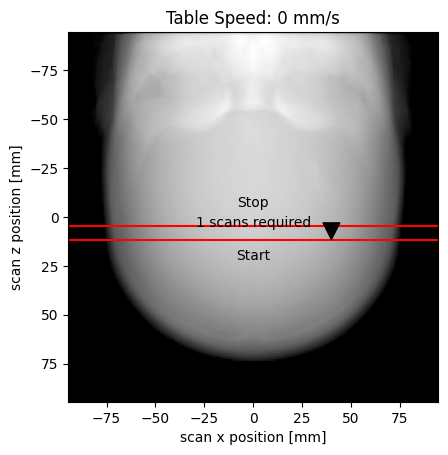

In [25]:
lesion_level_mm = (phantom.get_CT_number_phantom().shape[0]/2 -
                   phantom._lesion_coords[0][0])*phantom.dz

scans = 1  # edit me

center = lesion_level_mm
scan_width = 7
width = scan_width*scans
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

In [26]:
acquisition_technique = dict(
    mA=200,
    kVp=120,
    views=1000,
    startZ=startZ,
    endZ=endZ
)
scanner.run_scan(**acquisition_technique)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 1000/1000 [03:49<00:00,  4.36it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'pedsilicoICH.image_acquisition.Scanner'> default
        Scanner: CATSIM
        

In [27]:
recon_technique = dict(
    kernel='soft',
    fov=250,
    sliceThickness=1
)
scanner.run_recon(**recon_technique)

0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'pedsilicoICH.image_acquisition.Scanner'> default
        Scanner: CATSIM
        
Recon: (7, 512, 512) 25.0 cm fov
Projections: (1000, 16, 900)

## View the result

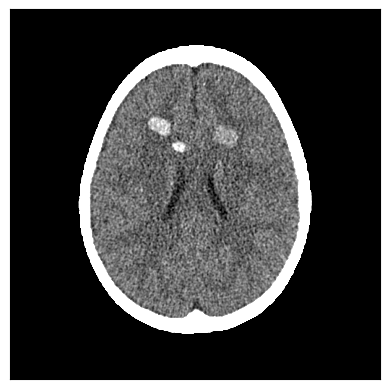

In [28]:
import sys
sys.path.append('..')
from utils import ctshow
ctshow(scanner.recon, 'brain')

In [29]:
from utils import scrollview
scrollview(scanner.recon, 'brain')

interactive(children=(IntSlider(value=3, description='idx', max=6), Output()), _dom_classes=('widget-interact'…

## Going Deeper

Below are more advance topics on how to get the lesion mask in the reconstructed image space and exploring more acquisition and reconstruction parameters

In [30]:
scanner.get_lesion_mask?

Signature:
scanner.get_lesion_mask(
    startZ: int | None = None,
    endZ: int | None = None,
    slice_thickness=1,
) -> numpy.ndarray[bool]
Docstring:
takes lesion in object space and returns a mask in CT image space
for the given imaging system
File:      ~/Dev/PedSilicoICH/src/pedsilicoICH/image_acquisition.py
Type:      method

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'water']
* mu values (/cm): [0.05, 0.21]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.19]
* Thresholds (HU): [-1000.0, -100.0]
*********************************************
* Calculating volume fraction maps for 2 materials and 189 slices...
* Writing volume fraction files for 2 materials and 189 slices, plus the HU data...
* Writing default/lesion_mask/lesion only/phantoms/0/0_ICRU_lung_adult_healthy_197x233x189.raw...
* 

  0%|          | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.


  1%|          | 1/100 [00:01<01:54,  1.15s/it]

in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:08<00:00, 12.14it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
0.02
-1
0.02
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


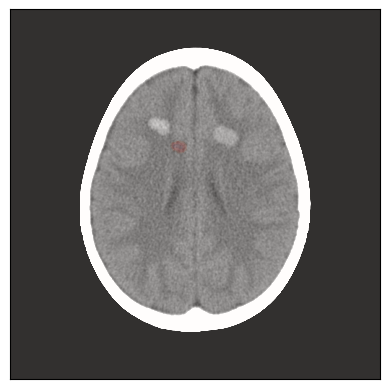

In [31]:
import matplotlib.pyplot as plt
mask = scanner.get_lesion_mask(startZ=startZ, endZ=endZ)
ctshow(scanner.recon.mean(axis=0), 'brain')
plt.imshow(mask.mean(axis=0), cmap='Reds', alpha=0.2)

In [32]:
mAs = [20, 80, 320]
mA_recons = []
for mA in mAs:
    scanner.run_scan(mA=mA, startZ=startZ, endZ=endZ, views=500)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    mA_recons.append(scanner.recon)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [01:53<00:00,  4.41it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
scan: 1/1
Airscan
Offset scan
Phantom scan


...

Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [01:52<00:00,  4.46it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


In [33]:
lesion_mask = scanner.get_lesion_mask(startZ=startZ, endZ=endZ)
lesion_mask.shape

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'water']
* mu values (/cm): [0.05, 0.21]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.19]
* Thresholds (HU): [-1000.0, -100.0]
*********************************************
* Calculating volume fraction maps for 2 materials and 189 slices...
* Writing volume fraction files for 2 materials and 189 slices, plus the HU data...
* Writing default/lesion_mask/lesion only/phantoms/0/0_ICRU_lung_adult_healthy_197x233x189.raw...
* 

  0%|          | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.


  1%|          | 1/100 [00:01<02:20,  1.42s/it]

in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:08<00:00, 11.86it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
0.02
-1
0.02
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


(7, 512, 512)

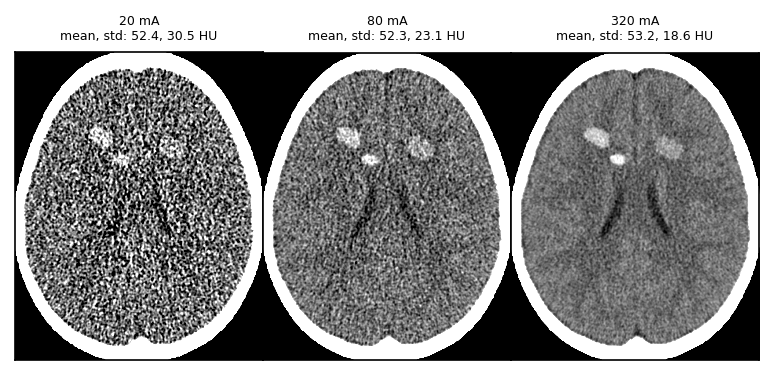

In [34]:
import sys
sys.path.append('..')
from utils import ctshow, center_crop
import matplotlib.pyplot as plt

f, axs = plt.subplots(1, len(mA_recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, mA in zip(axs.flatten(), mA_recons, mAs):
    ctshow(center_crop(recon[0]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{mA} mA\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)

In [35]:
kVps = [80, 100, 120, 140]
kVp_recons = []
for kVp in kVps:
    mA = 200 * (120 / kVp)**2 # accounts for the fact that tube output scales by kVp^2
    print(f'{kVp} kVp, {mA} mA')
    scanner.run_scan(kVp=kVp, mA=mA, startZ=startZ, endZ=endZ, views=500)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    kVp_recons.append(scanner.recon)

80 kVp, 450.0 mA
scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [01:52<00:00,  4.44it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
100 kVp, 288.0 mA
scan: 1/1
Airscan
Offset scan
Phantom scan


...

Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
140 kVp, 146.93877551020407 mA
scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [01:54<00:00,  4.36it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


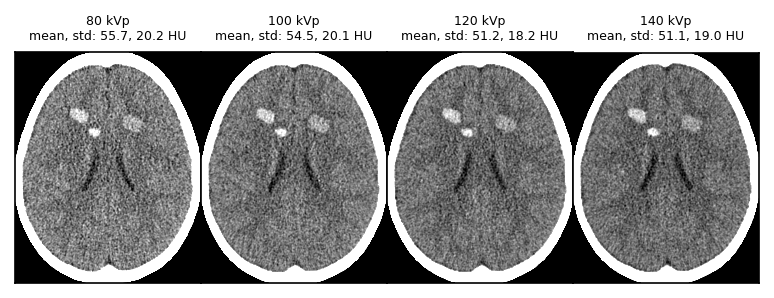

In [36]:
f, axs = plt.subplots(1, len(kVp_recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, kVp in zip(axs.flatten(), kVp_recons, kVps):
    ctshow(center_crop(recon[0]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{kVp} kVp\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)
    

In [37]:
scanner.run_scan(kVp=120, mA=200, startZ=startZ, endZ=endZ, views=500)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [01:51<00:00,  4.47it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'pedsilicoICH.image_acquisition.Scanner'> default
        Scanner: CATSIM
        
Recon: (7, 512, 512) 25.0 cm fov
Projections: (500, 16, 900)

In [38]:
kernels = ['bone', 'standard', 'soft']

recons = []
for kernel in kernels:
    scanner.run_recon(sliceThickness=1, kernel=kernel)
    recons.append(scanner.recon)

0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
0.02
-1
0.02
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting 

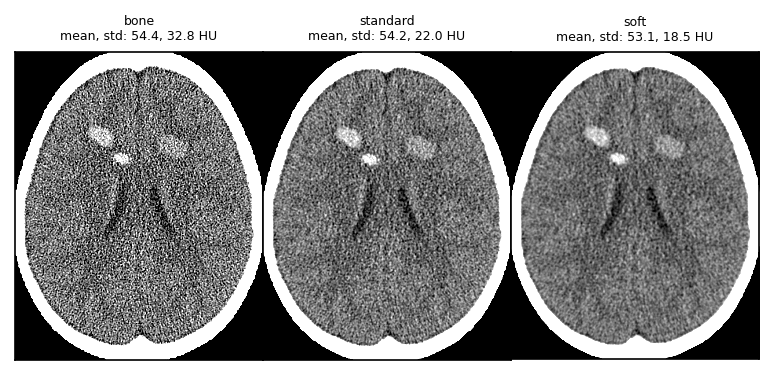

In [39]:
f, axs = plt.subplots(1, len(recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, kernel in zip(axs.flatten(), recons, kernels):
    ctshow(center_crop(recon[0]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{kernel}\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)